# Use ONNX model converted from TensorFlow to recognize hand-written digits with `ibm-watsonx-ai`

This notebook facilitates `ONNX`, `Tensorflow (and TF.Keras)`, and watsonx.ai Runtime service. It contains steps and code to work with [ibm-watsonx-ai](https://pypi.python.org/pypi/ibm-watsonx-ai) library available in PyPI repository in order to convert the TensorFlow model to ONNX format. It also introduces commands for getting model and training data, persisting model, deploying model and scoring it.

Some familiarity with Python is helpful. This notebook uses Python 3.12.

## Learning goals

The learning goals of this notebook are:

-  Download an externally trained TensorFlow model with dataset.
-  Convert TensorFlow model to ONNX format 
-  Persist converted model in watsonx.ai Runtime repository.
-  Deploy model for online scoring using client library.
-  Score sample records using client library.


## Contents

This notebook contains the following parts:

1. [Set up the environment](#1.-Set-up-the-environment)
2. [Downloading externally created TensorFlow model and data](#2.-Downloading-externally-created-TensorFlow-model-and-data)
3. [Converting TensorFlow model to ONNX format](#3.-Converting-TensorFlow-model-to-ONNX-format)
4. [Persisting converted ONNX model](#4.-Persisting-converted-ONNX-model)
5. [Deploying and scoring ONNX model](#5.-Deploying-and-scoring-ONNX-model)
6. [Cleanup](#6.-Cleanup)
7. [Summary and next steps](#7.-Summary-and-next-steps)

<a id="1.-Set-up-the-environment"></a>
## 1. Set up the environment

Before you use the sample code in this notebook, you must perform the following setup tasks:

-  Create a [watsonx.ai Runtime](https://cloud.ibm.com/catalog/services/watsonxai-runtime) instance (information on service plans and further reading can be found [here](https://dataplatform.cloud.ibm.com/docs/content/wsj/getting-started/wml-plans.html?context=wx&audience=wdp)).

### Install dependencies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install wget | tail -n 1
%pip install matplotlib | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1
%pip install "tensorflow==2.18" | tail -n 1
%pip install "tf2onnx==1.16" | tail -n 1
%pip install "onnxruntime==1.21.0" | tail -n 1
%pip install "numpy>=1.26.4,<2" | tail -n 1

### Connection to watsonx.ai Runtime

Authenticate the watsonx.ai Runtime service on IBM Cloud. You need to provide platform `api_key` and instance `location`.

You can use [IBM Cloud CLI](https://cloud.ibm.com/docs/cli/index.html) to retrieve platform API Key and instance location.

API Key can be generated in the following way:
```
ibmcloud login
ibmcloud iam api-key-create API_KEY_NAME
```

In result, get the value of `api_key` from the output.


Location of your watsonx.ai Runtime instance can be retrieved in the following way:
```
ibmcloud login --apikey API_KEY -a https://cloud.ibm.com
ibmcloud resource service-instance INSTANCE_NAME
```

In result, get the value of `location` from the output.

**Tip**: Your `Cloud API key` can be generated by going to the [**Users** section of the Cloud console](https://cloud.ibm.com/iam#/users). From that page, click your name, scroll down to the **API Keys** section, and click **Create an IBM Cloud API key**. Give your key a name and click **Create**, then copy the created key and paste it below. You can also get a service specific url by going to the [**Endpoint URLs** section of the watsonx.ai Runtime docs](https://cloud.ibm.com/apidocs/machine-learning).  You can check your instance location in your  <a href="https://cloud.ibm.com/catalog/services/watsonxai-runtime" target="_blank" rel="noopener no referrer">watsonx.ai Runtime Service</a> instance details.

You can also get service specific apikey by going to the [**Service IDs** section of the Cloud Console](https://cloud.ibm.com/iam/serviceids).  From that page, click **Create**, then copy the created key and paste it below.

**Action**: Enter your `url` and `api_key` in the following cell.

In [2]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    url="https://us-south.ml.cloud.ibm.com",
    api_key=getpass.getpass("Please enter your watsonx.ai api key (hit enter): "),
)

In [3]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### 1.3. Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use [Deployment Spaces Dashboard](https://dataplatform.cloud.ibm.com/ml-runtime/spaces?context=cpdaas) to create one.

- Click New Deployment Space
- Create an empty space
- Select Cloud Object Storage
- Select watsonx.ai Runtime instance and press Create
- Copy `space_id` and paste it below

**Tip**: You can also use the `ibm_watsonx_ai` SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watson-machine-learning-samples/blob/master/cloud/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [4]:
space_id = "ENTER YOUR SPACE ID HERE"

You can use `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

To be able to interact with all resources available in watsonx.ai Runtime, you need to set **space** which you will be using.

In [5]:
client.set.default_space(space_id)

'SUCCESS'

<a id="2.-Downloading-externally-created-TensorFlow-model-and-data"></a>
## 2. Downloading externally created TensorFlow model and data
In this section, you will download externally created TensorFlow models and data used for training it. You can choose to download either a **TensorFlow** or a **Keras** model.

### 2.1. Downloading dataset

In [6]:
from pathlib import Path

data_dir = Path("MNIST_DATA")
if not data_dir.is_dir():
    data_dir.mkdir()

In [7]:
import wget

data_path = data_dir / "mnist.npz"
if not data_path.is_file():
    wget.download("https://s3.amazonaws.com/img-datasets/mnist.npz", out=str(data_dir))

In [8]:
import numpy as np

dataset = np.load(data_path)
x_test = dataset["x_test"]

### 2.2. Downloading TensorFlow model

In [9]:
tf_model_name = "mnist-tf-model"
model_tar_name = f"{tf_model_name}.tar.gz"
model_path = data_dir / model_tar_name

if not model_path.is_file():
    wget.download(
        f"https://github.com/IBM/watsonx-ai-samples/raw/master/cloud/models/tensorflow/mnist/{model_tar_name}",
        out=str(data_dir),
    )

<a id="3.-Converting-TensorFlow-model-to-ONNX-format"></a>
## 3. Converting TensorFlow model to ONNX format
In this section, you will unpack externally created TensorFlow models, provided in either SavedModel or Keras format (depending on your earlier selection), from the tar archive and convert them to the ONNX format. More information can be found [here](https://onnxruntime.ai/docs/tutorials/tf-get-started.html).

In [10]:
onnx_model_name = "tf_model.onnx"

### 3.1. Converting TensorFlow SavedModel

In [11]:
import os
import tarfile

os.makedirs(tf_model_name, exist_ok=True)

tar_path = f"MNIST_DATA/{model_tar_name}"
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=tf_model_name, filter="data")

**Note:** If you are working with TensorFlow Lite models, make sure to use the `--tflite` flag instead of `--saved-model`.

**Tip:** You can also run this command from the CLI:
```sh
python -m tf2onnx.convert --saved-model $tf_model_name --output $onnx_model_name
```

In [12]:
import logging
import runpy
import sys

old_argv = sys.argv

try:
    sys.argv = ["python", "--saved-model", tf_model_name, "--output", onnx_model_name]
    runpy.run_module("tf2onnx.convert", run_name="__main__")
finally:
    sys.argv = old_argv
    logging.getLogger().setLevel(logging.WARNING)

<frozen runpy>:128: RuntimeWarning: 'tf2onnx.convert' found in sys.modules after import of package 'tf2onnx', but prior to execution of 'tf2onnx.convert'; this may result in unpredictable behaviour
2026-07-21 08:46:45,919 - WARNING - ***IMPORTANT*** Installed protobuf is not cpp accelerated. Conversion will be extremely slow. See https://github.com/onnx/tensorflow-onnx/issues/1557
2026-07-21 08:46:45,920 - WARNING - '--tag' not specified for saved_model. Using --tag serve
2026-07-21 08:46:46,065 - INFO - Signatures found in model: [serving_default].
2026-07-21 08:46:46,065 - WARNING - '--signature_def' not specified, using first signature: serving_default
2026-07-21 08:46:46,065 - INFO - Output names: ['output_0']
2026-07-21 08:46:46,065 - WARNING - Could not search for non-variable resources. Concrete function internal representation may have changed.
I0000 00:00:1784616406.070060   56676 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: Ten

In [13]:
import onnx

onnx_model = onnx.load(onnx_model_name)

### 3.2. (OPTIONAL) Converting TensorFLow Keras model

To convert the TensorFLow Keras model to ONNX format, change the `Markdown` cells below to a `Code` cells and remove the triple backticks (` ``` `).

```
!tar xzf MNIST_DATA/{model_tar_name}
```

```py
import logging

from keras.models import load_model

logging.getLogger().setLevel(logging.ERROR)

model = load_model(tf_model_name)
onnx_model, _ = tf2onnx.convert.from_keras(model)
onnx.save(onnx_model, onnx_model_name)
```

<a id="3.3.-Evaluating-the-ONNX-Model"></a>
### 3.3. Evaluating the ONNX Model

After exporting the model, you should verify its integrity and ensure that it functions as expected. We will use `onnxruntime` to load the model and perform inference on the test data. Additionally, we’ll use `onnx`'s `checker` module to validate the exported ONNX model.


In [14]:
onnx.checker.check_model(onnx_model)

In [15]:
import onnxruntime as ort

session = ort.InferenceSession(onnx_model_name)
x_test = np.array(x_test, dtype=np.float32).reshape(-1, 28, 28, 1)
input_data = {session.get_inputs()[0].name: x_test[:2]}
session.run([], input_data)

[array([[2.9459990e-11, 2.6513208e-10, 5.7859739e-09, 1.4021280e-08,
         9.0819036e-10, 2.0454895e-07, 3.2107092e-08, 9.9999964e-01,
         8.8907576e-08, 3.6024445e-10],
        [1.1899501e-06, 2.6128285e-03, 9.7718209e-01, 1.6054348e-06,
         4.1321553e-07, 1.1023610e-06, 2.0009710e-02, 3.6875292e-08,
         1.9093615e-04, 1.7123283e-07]], dtype=float32)]

<a id="4.-Persisting-converted-ONNX-model"></a>
## 4. Persisting converted ONNX model

In this section, you will learn how to store your converted ONNX model in watsonx.ai Runtime repository using the IBM watsonx.ai SDK.

### 4.1. Publishing model in watsonx.ai Runtime repository

Define model name, type and software spec.

In [16]:
software_spec_id = client.software_specifications.get_id_by_name("onnxruntime_opset_21")
onnx_model_zip = "tf_onnx.zip"

In [17]:
import zipfile

with zipfile.ZipFile(onnx_model_zip, "w", zipfile.ZIP_DEFLATED) as zip_file:
    zip_file.write(onnx_model_name)

In [18]:
metadata = {
    client.repository.ModelMetaNames.NAME: "TensorFlow to ONNX converted model",
    client.repository.ModelMetaNames.TYPE: "onnxruntime_1.17",
    client.repository.ModelMetaNames.SOFTWARE_SPEC_ID: software_spec_id,
}

published_model = client.repository.store_model(
    model=onnx_model_zip, meta_props=metadata
)

### 4.2. Getting model details

In [19]:
import json

published_model_id = client.repository.get_model_id(published_model)
model_details = client.repository.get_details(published_model_id)
print(json.dumps(model_details, indent=2))

{
  "metadata": {
    "name": "TensorFlow to ONNX converted model",
    "space_id": "ec654d74-517e-45b0-8cfa-0b355266b56a",
    "resource_key": "ab0bb924-953e-43a6-9158-6fa36034769e",
    "id": "019f836d-56e2-74c0-998b-6eb48cfaa274",
    "created_at": "2026-07-21T06:46:48Z",
    "rov": {
      "member_roles": {
        "IBMid-696000GJGB": {
          "user_iam_id": "IBMid-696000GJGB",
          "roles": [
            "OWNER"
          ]
        }
      }
    },
    "owner": "IBMid-696000GJGB"
  },
  "entity": {
    "software_spec": {
      "id": "d0b5361f-0810-554e-8d7b-874b5ff799b1"
    },
    "type": "onnxruntime_1.17"
  }
}


<a id="5.-Deploying-and-scoring-ONNX-model"></a>
## 5. Deploying and scoring ONNX model

In this section you'll learn how to create an online scoring service and predict on unseen data.

### 5.1. Creating online deployment for published model

In [20]:
metadata = {
    client.deployments.ConfigurationMetaNames.NAME: "Deployment of TensorFLow to ONNX converted model",
    client.deployments.ConfigurationMetaNames.ONLINE: {},
}

created_deployment = client.deployments.create(published_model_id, meta_props=metadata)



######################################################################################

Synchronous deployment creation for id: '019f836d-56e2-74c0-998b-6eb48cfaa274' started

######################################################################################


initializing
Note: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.
......
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='019f836d-8179-76b4-89d5-5f93c274f772'
-----------------------------------------------------------------------------------------------




In [21]:
deployment_id = client.deployments.get_id(created_deployment)

Now you can print an online scoring endpoint. 

In [22]:
client.deployments.get_scoring_href(created_deployment)

### 5.2. Getting deployment details

In [23]:
client.deployments.get_details(deployment_id)

### 5.3. Scoring

You can use below method to do test scoring request against deployed model.

Let's first visualize two samples from dataset, we'll use for scoring.

In [24]:
%matplotlib inline

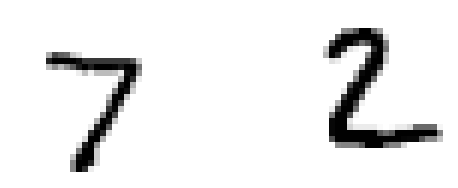

In [25]:
import matplotlib.pyplot as plt

for i, image in enumerate([x_test[0], x_test[1]]):
    plt.subplot(2, 2, i + 1)
    plt.axis("off")
    plt.imshow(image.reshape((28, 28)), cmap=plt.cm.gray_r, interpolation="nearest")

Prepare scoring payload with records to score.

In [26]:
scoring_payload = {"input_data": [{"values": x_test[:2].tolist()}]}

Use ``client.deployments.score()`` method to run scoring.

In [27]:
predictions = client.deployments.score(deployment_id, scoring_payload)

Let's print the result of predictions.

In [28]:
print(json.dumps(predictions, indent=2))

{
  "predictions": [
    {
      "id": "output_0",
      "values": [
        [
          2.9460045514184685e-11,
          2.651320829549775e-10,
          5.78599612666153e-09,
          1.402130678229696e-08,
          9.081955743006631e-10,
          2.0454953642001783e-07,
          3.2107216441090713e-08,
          0.9999996423721313,
          8.890791747262483e-08,
          3.6024583316418557e-10
        ],
        [
          1.1899520586666767e-06,
          0.0026128317695111036,
          0.9771818518638611,
          1.6054360685302527e-06,
          4.13216241668124e-07,
          1.102363967220299e-06,
          0.020009761676192284,
          3.687535610197301e-08,
          0.00019093610171694309,
          1.7123278439612477e-07
        ]
      ]
    }
  ]
}


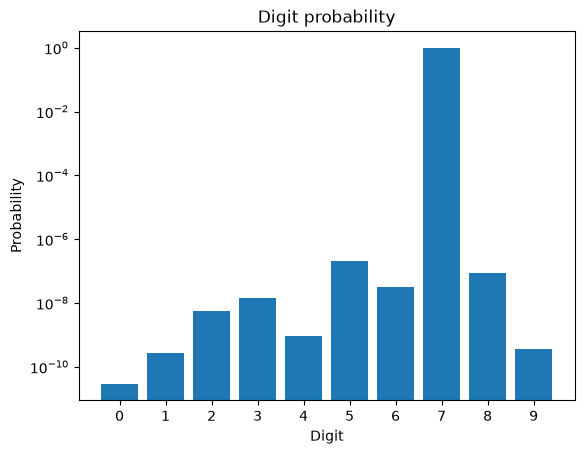

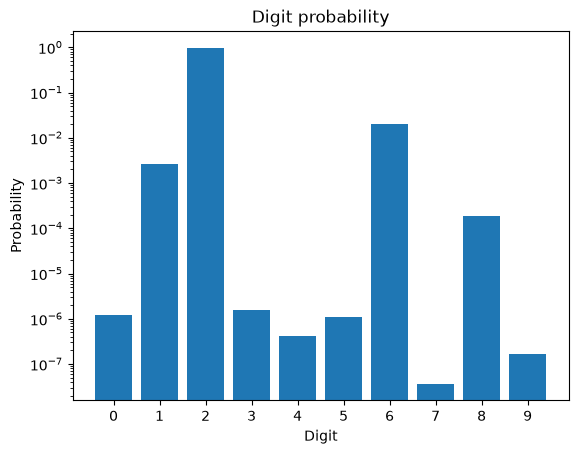

In [29]:
for i, prediction in enumerate(predictions["predictions"][0]["values"]):
    plt.bar(range(10), prediction)
    plt.title("Digit probability")
    plt.xlabel("Digit")
    plt.ylabel("Probability")
    plt.xticks(range(10))
    plt.yscale("log")
    plt.show()

As you can see, the predicted values are consistent with those calculated in the [evaluation](#3.3.-Evaluating-the-ONNX-Model) section.

<a id="6.-Cleanup"></a>
## 6. Cleanup

If you want to clean up after the notebook execution, i.e. remove any created assets like:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watson-machine-learning-samples/blob/master/cloud/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="7.-Summary-and-next-steps"></a>
## 7. Summary and next steps

 You successfully completed this notebook! You learned how to use ONNX, TensorFlow machine learning library as well as watsonx.ai for model creation and deployment. Check out our _[Online Documentation](https://dataplatform.cloud.ibm.com/docs/content/wsj/getting-started/welcome-main.html?context=wx)_ for more samples, tutorials, documentation, how-tos, and blog posts. 

### Authors

**Michał Koruszowic**, Software Engineer

Copyright © 2024-2026 IBM. This notebook and its source code are released under the terms of the MIT License.